# Auto-size & optimize: three production-optimization workflows

This notebook shows how to drive NeqSim's **production optimizer** with a minimum of Python.
The heavy lifting (auto-sizing equipment, building capacity constraints, the throughput search)
is done entirely inside Java NeqSim — Python only *builds the plant* and *reads results*.

It is a companion to the
[Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html).

| Scenario | What is given | Workflow |
|----------|---------------|----------|
| **A** | *Nothing* — only stream conditions | `autoSizeEquipment()` → optimize |
| **B** | A fully-specified, larger train (sizes / curves / datasheets) | size the equipment to the design duty → optimize |
| **C** | Nothing first, then a real (bigger) machine | auto-size → optimize → update with real sizes → re-optimize |

All three reuse the **same** tiny `size_for()` + `maximize_throughput()` helpers, so changing
the installed equipment is just changing one number — the throughput the plant is sized for.

In [1]:
import os, sys
from pathlib import Path


def find_neqsim_project_root():
    env_root = os.environ.get("NEQSIM_PROJECT_ROOT")
    candidates = []
    if env_root:
        candidates.append(Path(env_root).resolve())
    cwd = Path.cwd().resolve()
    candidates.extend([cwd] + list(cwd.parents))
    for candidate in candidates:
        if (candidate / "pom.xml").exists() and (candidate / "devtools" / "neqsim_dev_setup.py").exists():
            return candidate
    raise RuntimeError("Could not find NeqSim project root. Set NEQSIM_PROJECT_ROOT.")


PROJECT_ROOT = find_neqsim_project_root()
sys.path.insert(0, str(PROJECT_ROOT / "devtools"))
from neqsim_dev_setup import neqsim_init, neqsim_classes

ns = neqsim_init(project_root=PROJECT_ROOT, recompile=False, verbose=True)
ns = neqsim_classes(ns)
print("NeqSim loaded from workspace classes")

NeqSim project root: C:\Users\ESOL\Documents\GitHub\neqsim
Classpath:
  1. C:\Users\ESOL\Documents\GitHub\neqsim\target\classes
  2. C:\Users\ESOL\Documents\GitHub\neqsim\src\main\resources
  3. C:\Users\ESOL\Documents\GitHub\neqsim\target\neqsim-3.13.0.jar



JVM started: C:\Users\ESOL\graalvm\graalvm-jdk-25.0.1+8.1\bin\server\jvm.dll
Ready — call neqsim_classes(ns) to import classes


All NeqSim classes imported OK
NeqSim loaded from workspace classes


In [2]:
SystemSrkEos = ns.SystemSrkEos
ProcessSystem = ns.ProcessSystem
Stream = ns.Stream
Separator = ns.Separator
Compressor = ns.Compressor
Cooler = ns.Cooler

ProductionOptimizer = ns.JClass("neqsim.process.util.optimizer.ProductionOptimizer")
OptimizationConfig = ProductionOptimizer.OptimizationConfig
SearchMode = ProductionOptimizer.SearchMode

print("Process and optimizer classes imported")

Process and optimizer classes imported


## Small helper library

Everything below is reused by all three scenarios.

- `build_plant()` returns a tiny feed → separator → compressor → cooler train.
- `size_for()` sizes **every** unit (separator dimensions, compressor performance curve,
  cooler duty) to a chosen design throughput with one `autoSizeEquipment()` call.
- `maximize_throughput()` is the **only** call needed to run an optimization — NeqSim's
  `ProductionOptimizer` finds the highest feed rate that keeps every unit below its
  capacity limit. It searches around the duty the plant was sized for, so it works
  whether the equipment is small or large.

In [3]:
def build_plant(feed_rate_kghr=8000.0):
    """feed -> inlet separator -> export compressor -> export cooler."""
    fluid = SystemSrkEos(273.15 + 45.0, 60.0)
    for comp, x in [("methane", 0.80), ("ethane", 0.07), ("propane", 0.05),
                    ("n-butane", 0.03), ("n-pentane", 0.02), ("water", 0.03)]:
        fluid.addComponent(comp, x)
    fluid.setMixingRule("classic")
    fluid.setMultiPhaseCheck(True)

    feed = Stream("feed", fluid)
    feed.setFlowRate(feed_rate_kghr, "kg/hr")
    feed.setTemperature(45.0, "C")
    feed.setPressure(60.0, "bara")

    sep = Separator("inlet separator", feed)
    comp = Compressor("export compressor", sep.getGasOutStream())
    comp.setOutletPressure(140.0)
    comp.setPolytropicEfficiency(0.78)
    comp.setUsePolytropicCalc(True)
    cooler = Cooler("export cooler", comp.getOutletStream())
    cooler.setOutTemperature(35.0, "C")

    process = ProcessSystem()
    for u in [feed, sep, comp, cooler]:
        process.add(u)
    return {"process": process, "feed": feed, "sep": sep, "comp": comp, "cooler": cooler}


def size_for(plant, design_rate_kghr, safety=1.2):
    """Size every unit for a design throughput. One autoSizeEquipment() call sizes
    the separator, compressor curve and cooler to `safety` x the design duty."""
    plant["feed"].setFlowRate(design_rate_kghr, "kg/hr")
    plant["process"].run()
    plant["process"].autoSizeEquipment(safety)
    plant["process"].run()


def utilization(process):
    """Capacity utilization per unit, in percent (NeqSim already returns percent)."""
    out = {}
    for e in process.getCapacityUtilizationSummary().entrySet():
        out[str(e.getKey())] = round(float(e.getValue()), 1)
    return out


def show_bottleneck(process):
    b = process.findBottleneck()
    if b is None or b.getEquipment() is None:
        print("  bottleneck: none active")
        return
    print("  bottleneck: %s [%s] @ %.1f%%" % (
        b.getEquipmentName(), b.getConstraintName(), b.getUtilizationPercent()))


def maximize_throughput(plant, util_limit=0.95, span=0.30):
    """One call = full optimization. Searches around the duty the plant was sized
    for (the current feed rate), so it stays inside the compressor operating window."""
    process, feed = plant["process"], plant["feed"]
    design = feed.getFlowRate("kg/hr")
    lo, hi = (1.0 - span) * design, design
    config = (OptimizationConfig(lo, hi)
              .rateUnit("kg/hr")
              .tolerance(50.0)
              .maxIterations(25)
              .defaultUtilizationLimit(util_limit)
              .searchMode(SearchMode.BINARY_FEASIBILITY))
    return ProductionOptimizer().optimize(process, feed, config, None, None)


def report(tag, result):
    bott = result.getBottleneck().getName() if result.getBottleneck() is not None else "n/a"
    print("%s: optimal %.0f %s | feasible=%s | bottleneck=%s @ %.1f%%" % (
        tag, result.getOptimalRate(), result.getRateUnit(), result.isFeasible(),
        bott, result.getBottleneckUtilization() * 100.0))


print("Helpers ready")

Helpers ready


## Scenario A — nothing given, just auto-size

We know only the stream conditions. `size_for(...)` picks a nominal design duty
and `autoSizeEquipment(1.2)` sizes every unit (separator dimensions, compressor
performance curve, cooler duty) to 1.2× that duty and builds the capacity
constraints automatically. Then we ask for the maximum feasible throughput.

In [4]:
A = build_plant()
size_for(A, 8000.0)            # nothing known -> size for a nominal 8000 kg/hr
print("Auto-sized 3 units from flow conditions")
print("Utilization at design point:", utilization(A["process"]))
show_bottleneck(A["process"])

optA = maximize_throughput(A)
report("Scenario A", optA)
print("Utilization at optimum:", utilization(A["process"]))

Auto-sized 3 units from flow conditions
Utilization at design point: {'inlet separator': 83.0, 'export compressor': 98.7, 'export cooler': 82.8}
  bottleneck: export compressor [speed] @ 98.7%
Scenario A: optimal 6350 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at optimum: {'inlet separator': 66.7, 'export compressor': 95.1, 'export cooler': 65.1}


## Scenario B — most things given (sizes, curves, datasheets)

Here the installed train is fully specified: a **larger** compressor with its
performance curve and matching vessels, designed for ~12000 kg/hr. We capture
that by sizing the plant for the design duty. Individual equipment sizes can
also be set explicitly in one line — e.g. the real separator K-factor via
`setDesignGasLoadFactor` — and the optimizer immediately respects them. Because
the machine is bigger than Scenario A, the feasible export is higher.

In [5]:
B = build_plant()
size_for(B, 12000.0)                     # vendor datasheets: train designed for 12000 kg/hr

# Individual sizes can be overridden in one line (here: real separator K-factor):
B["sep"].setDesignGasLoadFactor(0.13)    # generous real separator [m/s] -> stays off the limit
B["process"].run()
print("Utilization at design point:", utilization(B["process"]))
show_bottleneck(B["process"])

optB = maximize_throughput(B)
report("Scenario B", optB)
print("Utilization at optimum:", utilization(B["process"]))

Utilization at design point: {'inlet separator': 68.3, 'export compressor': 98.7, 'export cooler': 82.8}
  bottleneck: export compressor [speed] @ 98.7%
Scenario B: optimal 9553 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at optimum: {'inlet separator': 54.5, 'export compressor': 95.0, 'export cooler': 64.7}


## Scenario C — nothing given → auto-size → update with real sizes → re-optimize

The full life-cycle: start with no data, auto-size and optimize for an early
estimate, then later the real datasheet arrives — the installed compressor is
rated for a higher duty. We re-size the **same** plant for the real machine and
re-optimize. The same helpers are reused — only the design duty changed.

In [6]:
C = build_plant()
size_for(C, 8000.0)                      # 1) nothing known -> auto-size for 8000 kg/hr
optC_auto = maximize_throughput(C)
report("Scenario C (auto-sized)", optC_auto)

size_for(C, 10000.0)                     # 2) real datasheet: installed machine rated for 10000 kg/hr
optC_real = maximize_throughput(C)
report("Scenario C (real sizes)", optC_real)

print("Utilization at real-size optimum:", utilization(C["process"]))
print("Throughput change after using real sizes: %+.0f kg/hr" % (
    optC_real.getOptimalRate() - optC_auto.getOptimalRate()))

Scenario C (auto-sized): optimal 6350 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%


Scenario C (real sizes): optimal 7234 kg/hr | feasible=True | bottleneck=export compressor @ 95.0%
Utilization at real-size optimum: {'inlet separator': 60.0, 'export compressor': 95.0, 'export cooler': 52.9}
Throughput change after using real sizes: +884 kg/hr


## Compare the three workflows

The bars show the maximum feasible throughput from each workflow. All three are
limited by the export compressor's performance curve — the larger the machine the
plant is sized for, the more it can export. Scenario B's train is sized for the
biggest design duty, so it reaches the highest feasible rate. The faded bar shows
Scenario C *before* the real (larger) machine sizes were applied.

Saved figure: C:\Users\ESOL\Documents\GitHub\neqsim\examples\notebooks\figures\autosize_optimize_scenarios.png


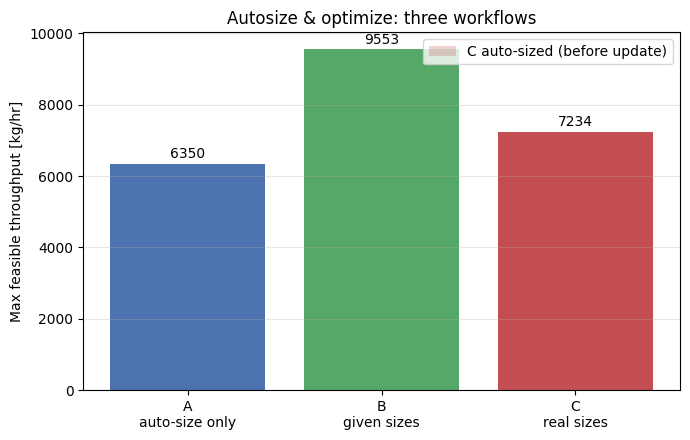

In [7]:
import matplotlib.pyplot as plt

labels = ["A\nauto-size only", "B\ngiven sizes", "C\nreal sizes"]
rates = [optA.getOptimalRate(), optB.getOptimalRate(), optC_real.getOptimalRate()]

fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(labels, rates, color=["#4C72B0", "#55A868", "#C44E52"])
ax.bar(["C\nreal sizes"], [optC_auto.getOptimalRate()], color="#C44E52",
       alpha=0.25, label="C auto-sized (before update)")
for b, r in zip(bars, rates):
    ax.text(b.get_x() + b.get_width() / 2, r + 80, "%.0f" % r,
            ha="center", va="bottom", fontsize=10)
ax.set_ylabel("Max feasible throughput [kg/hr]")
ax.set_title("Autosize & optimize: three workflows")
ax.grid(axis="y", alpha=0.3)
ax.legend()
fig.tight_layout()

figdir = PROJECT_ROOT / "examples" / "notebooks" / "figures"
figdir.mkdir(parents=True, exist_ok=True)
figpath = figdir / "autosize_optimize_scenarios.png"
fig.savefig(figpath, dpi=150, bbox_inches="tight")
print("Saved figure:", figpath)
plt.show()

## Bonus — energy/CO₂ vs production: a Pareto trade-off

The three scenarios above answer *"how much can I produce?"*. Real plants also have to answer
*"how much should I produce?"* — because **more throughput costs more shaft power, and shaft
power costs energy and CO₂**. These two goals genuinely conflict, so the right tool is a
**Pareto** sweep, not a single optimum.

NeqSim already supports this through `ProductionOptimizer.optimizePareto(...)`:

- **Objectives** — maximise export-gas production *and* minimise energy/CO₂ (taken as shaft
  power × an emission factor, here 0.50 kg CO₂/kWh for a gas-turbine driver). Both are
  normalised to O(1) so the weighted-sum scalarisation is balanced.
- **Soft penalty** — keep the compressor ≥ 5 % off surge via an
  `OptimizationConstraint.greaterThan(..., ConstraintSeverity.SOFT, ...)`. Soft constraints
  bend the search rather than rejecting points outright.
- The optimizer sweeps a grid of objective weights, runs the convergence-gated throughput
  search for each, and returns the **non-dominated** operating points.

No new Java is needed — this reuses the same `build_plant()` / `size_for()` helpers.

In [8]:
import jpype

# Multi-objective inner classes (already on ProductionOptimizer).
OptimizationObjective = ProductionOptimizer.OptimizationObjective
ObjectiveType = ProductionOptimizer.ObjectiveType
OptimizationConstraint = ProductionOptimizer.OptimizationConstraint
ConstraintSeverity = ProductionOptimizer.ConstraintSeverity
ArrayList = ns.JClass("java.util.ArrayList")

EF_CO2 = 0.50        # kg CO₂ per kWh of shaft power (gas-turbine driver proxy)
DESIGN = 12000.0     # installed train design throughput [kg/hr]
REF_PROD = DESIGN    # normalisers -> both objectives are O(1) for the weighted sum
REF_PWR = 360.0

# Install a 12 t/hr train, then optimise on it.
pareto_plant = build_plant()
size_for(pareto_plant, DESIGN)
pr_process, pr_feed = pareto_plant["process"], pareto_plant["feed"]


def _export(p):
    return p.getUnit("export cooler").getOutletStream().getFlowRate("kg/hr")


def _power(p):
    return p.getUnit("export compressor").getPower("kW")


def _surge(p):
    return p.getUnit("export compressor").getDistanceToSurge()


def _proxy(fn):
    """Wrap a Python function as a Java ToDoubleFunction<ProcessSystem>."""
    return jpype.JProxy("java.util.function.ToDoubleFunction", dict(applyAsDouble=fn))


# Two conflicting objectives: maximise production, minimise energy/CO₂ (∝ shaft power).
objectives = ArrayList()
objectives.add(OptimizationObjective(
    "production", _proxy(lambda p: _export(p) / REF_PROD), 1.0, ObjectiveType.MAXIMIZE))
objectives.add(OptimizationObjective(
    "energy_co2", _proxy(lambda p: _power(p) / REF_PWR), 1.0, ObjectiveType.MINIMIZE))

# Soft penalty: keep the compressor at least 5 % off surge (never a hard stop).
constraints = ArrayList()
constraints.add(OptimizationConstraint.greaterThan(
    "surge_margin", _proxy(_surge), 0.05, ConstraintSeverity.SOFT, 5.0, "stay >5% off surge"))

cfg = (OptimizationConfig(0.70 * DESIGN, DESIGN)
       .rateUnit("kg/hr")
       .tolerance(50.0)
       .maxIterations(25)
       .defaultUtilizationLimit(0.95)
       .searchMode(SearchMode.GOLDEN_SECTION_SCORE)
       .paretoGridSize(7))

pareto = ProductionOptimizer().optimizePareto(pr_process, pr_feed, cfg, objectives, constraints)
print("Pareto front points:", pareto.getParetoFrontSize())
print(pareto.toMarkdownTable())

Pareto front points: 2
| # | Feasible | production | energy_co2 | Weights |
|---|---|---|---|---|
| 1 | yes | 0.7728 | 0.9155 | [1.00, 0.00] |
| 2 | yes | 0.6849 | 0.8071 | [0.33, 0.67] |



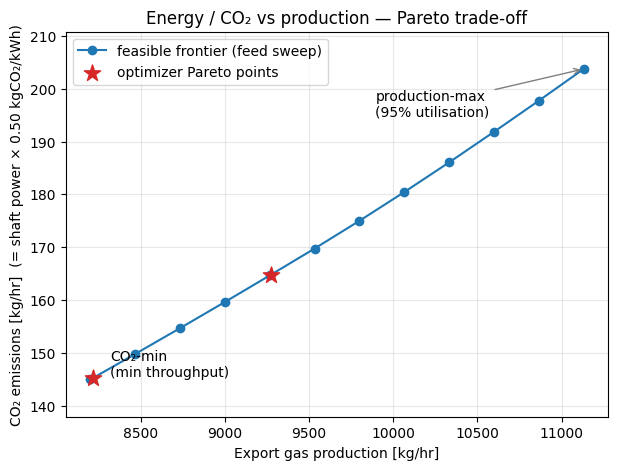

Specific emissions: 0.0177 -> 0.0183 kg CO₂/kg gas (3.6% rise across the window)


In [9]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

# Continuous feasible frontier: sweep the feed across the operating window.
rates = np.linspace(0.70 * DESIGN, 0.95 * DESIGN, 12)
prod, co2 = [], []
for r in rates:
    pr_feed.setFlowRate(float(r), "kg/hr")
    pr_process.run()
    prod.append(_export(pr_process))
    co2.append(_power(pr_process) * EF_CO2)
prod, co2 = np.array(prod), np.array(co2)

# The optimizer's non-dominated points (re-evaluated in real units).
pf_prod, pf_co2 = [], []
for pt in pareto.getParetoFront():
    feed_rate = list(pt.getDecisionVariables().values())[0]
    pr_feed.setFlowRate(float(feed_rate), "kg/hr")
    pr_process.run()
    pf_prod.append(_export(pr_process))
    pf_co2.append(_power(pr_process) * EF_CO2)

fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(prod, co2, "-o", color="#1f77b4", label="feasible frontier (feed sweep)")
ax.scatter(pf_prod, pf_co2, s=150, marker="*", color="#d62728", zorder=5,
           label="optimizer Pareto points")
ax.annotate("CO₂-min\n(min throughput)", (prod[0], co2[0]),
            textcoords="offset points", xytext=(14, 2))
ax.annotate("production-max\n(95% utilisation)", (prod[-1], co2[-1]),
            textcoords="offset points", xytext=(-150, -34),
            arrowprops=dict(arrowstyle="->", color="0.5"))
ax.set_xlabel("Export gas production [kg/hr]")
ax.set_ylabel("CO₂ emissions [kg/hr]  (= shaft power × %.2f kgCO₂/kWh)" % EF_CO2)
ax.set_title("Energy / CO₂ vs production — Pareto trade-off")
ax.margins(y=0.12)
ax.grid(True, alpha=0.3)
ax.legend(loc="upper left")
figdir = Path("figures")
figdir.mkdir(exist_ok=True)
fig.savefig(figdir / "pareto_energy_co2_vs_production.png", dpi=150, bbox_inches="tight")
plt.show()

intensity = co2 / prod
print("Specific emissions: %.4f -> %.4f kg CO₂/kg gas (%.1f%% rise across the window)" % (
    intensity.min(), intensity.max(), 100.0 * (intensity.max() / intensity.min() - 1.0)))

**Reading the Pareto front.** On this single-train, fixed-discharge-pressure plant the
trade-off is almost a straight line: CO₂ scales nearly linearly with throughput, so *every*
feasible rate between the CO₂-minimum (lowest throughput) and the production-maximum
(95 % utilisation) is **non-dominated** — picking an operating point is a business preference,
not a hidden technical optimum. The specific emissions (kg CO₂ / kg gas) still rise modestly
toward the high-flow end, where the compressor runs less efficiently.

The front becomes a genuinely *curved* 2-D Pareto surface as soon as a second knob enters that
trades power against recovery (e.g. export pressure, or a recompression/recycle that recovers
more liquids at the cost of shaft power). The same `optimizePareto(...)` call and soft-penalty
constraints handle that case — just pass a list of `ManipulatedVariable`s instead of the feed
stream. See the
[Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html)
for the multi-variable form.

## Takeaways

- **Minimal Python.** One `build_plant()` builder, a handful of helpers, and a single
  `maximize_throughput()` call drive every scenario. All sizing, constraint building and the
  throughput search happen inside Java NeqSim.
- **Works with little input.** Scenario A starts from nothing but stream conditions —
  `autoSizeEquipment()` makes the plant optimizable in one call.
- **Easy to modify sizes.** Supplying real equipment data is a one-line change
  (`size_for(...)` for the design duty, or `setDesignGasLoadFactor` for an explicit
  separator size), and the optimizer immediately reflects the new binding constraint.
- **Full life-cycle.** Scenario C shows the common pattern: auto-size for an early estimate,
  then update with the real (larger) installed machine and re-optimize using the *same* code.

See the [Production Optimization Guide](https://equinor.github.io/neqsim/examples/PRODUCTION_OPTIMIZATION_GUIDE.html)
for the full optimizer API (custom objectives, multiple decision variables, utilization limits).